# FMA-Medium Dataset Inspection
**Goal:** Inspect the FMA-medium dataset to select 10 broad genres with sufficient samples for rebuilding our genre classification model.

Steps:
1. Download FMA-medium audio + metadata
2. Extract audio files
3. Load metadata CSVs
4. Identify top-level genre labels
5. Count tracks per genre
6. Select best 10 genres for training

## 1. Import Required Libraries

In [1]:
import os
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

# ── Paths ────────────────────────────────────────────────────────
PROJECT_ROOT = os.path.dirname(os.path.abspath("__file__"))  # training/
PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)                  # Muud/
DATA_DIR     = os.path.join(PROJECT_ROOT, "data", "FMA")

os.makedirs(DATA_DIR, exist_ok=True)
print(f"Data directory: {DATA_DIR}")

Data directory: C:\Users\adith\Documents\Study\Coding\Muud\data\FMA


## 2. Download FMA-Medium Dataset and Metadata

FMA download URLs (from the [official GitHub repo](https://github.com/mdeff/fma)):
- **fma_medium.zip** — 25,000 tracks × 30 s, 22 GiB
- **fma_metadata.zip** — CSVs with track/genre/feature info, ~350 MiB

> **Note:** These are large files. The cell below will skip any file that already exists.

In [2]:
# FMA download URLs
URLS = {
    "fma_metadata.zip": "https://os.unil.cloud.switch.ch/fma/fma_metadata.zip",
    "fma_medium.zip":   "https://os.unil.cloud.switch.ch/fma/fma_medium.zip",
}

import sys, time

def download_file(url: str, dest_path: str) -> None:
    """Download *url* to *dest_path* with live progress, skipping if already present."""
    if os.path.exists(dest_path):
        size_mb = os.path.getsize(dest_path) / 1e6
        print(f"  ✓ Already exists: {os.path.basename(dest_path)} ({size_mb:.1f} MB)")
        return

    basename = os.path.basename(dest_path)
    start_time = time.time()

    def _progress(block_num, block_size, total_size):
        downloaded = block_num * block_size
        if total_size > 0:
            pct = min(downloaded / total_size * 100, 100)
            dl_mb = downloaded / 1e6
            tot_mb = total_size / 1e6
            elapsed = time.time() - start_time
            speed = dl_mb / elapsed if elapsed > 0 else 0
            bar_len = 30
            filled = int(bar_len * pct / 100)
            bar = "█" * filled + "░" * (bar_len - filled)
            sys.stdout.write(
                f"\r  ↓ {basename}  |{bar}| {pct:5.1f}%  "
                f"{dl_mb:.1f}/{tot_mb:.1f} MB  ({speed:.1f} MB/s)"
            )
            sys.stdout.flush()
        else:
            dl_mb = downloaded / 1e6
            sys.stdout.write(f"\r  ↓ {basename}  {dl_mb:.1f} MB downloaded …")
            sys.stdout.flush()

    print(f"  ↓ Downloading {basename} …")
    urllib.request.urlretrieve(url, dest_path, reporthook=_progress)
    size_mb = os.path.getsize(dest_path) / 1e6
    print(f"\n    ✓ Done ({size_mb:.1f} MB)")

# Download both archives
for name, url in URLS.items():
    download_file(url, os.path.join(DATA_DIR, name))

  ✓ Already exists: fma_metadata.zip (358.4 MB)
  ✓ Already exists: fma_medium.zip (23825.0 MB)


## 3. Extract Audio Files from Archive

Extract metadata CSVs first (small), then audio `.mp3` files from `fma_medium.zip`.

In [3]:
METADATA_DIR = os.path.join(DATA_DIR, "fma_metadata")
AUDIO_DIR    = os.path.join(DATA_DIR, "fma_medium")

def extract_zip(zip_path: str, dest_dir: str, extension: str | None = None) -> int:
    """Extract files from a zip archive.

    Args:
        zip_path:  Path to the .zip file.
        dest_dir:  Extraction target directory.
        extension: If set, only extract files ending with this suffix.

    Returns:
        Number of files extracted.
    """
    if os.path.isdir(dest_dir) and os.listdir(dest_dir):
        count = sum(1 for _, _, files in os.walk(dest_dir) for f in files)
        print(f"  ✓ Already extracted: {dest_dir}  ({count} files)")
        return count

    os.makedirs(dest_dir, exist_ok=True)
    count = 0
    with zipfile.ZipFile(zip_path, "r") as zf:
        members = zf.namelist()
        for m in members:
            if extension and not m.lower().endswith(extension):
                continue
            zf.extract(m, dest_dir)
            count += 1
    print(f"  Extracted {count} files → {dest_dir}")
    return count

# ── Extract metadata CSVs ──────────────────────────────────────
meta_zip = os.path.join(DATA_DIR, "fma_metadata.zip")
print("Metadata:")
extract_zip(meta_zip, METADATA_DIR)

# ── Extract audio MP3s ──────────────────────────────────────────
audio_zip = os.path.join(DATA_DIR, "fma_medium.zip")
print("\nAudio:")
n_audio = extract_zip(audio_zip, AUDIO_DIR, extension=".mp3")
print(f"\nTotal audio files: {n_audio}")

Metadata:
  Extracted 12 files → C:\Users\adith\Documents\Study\Coding\Muud\data\FMA\fma_metadata

Audio:
  Extracted 25000 files → C:\Users\adith\Documents\Study\Coding\Muud\data\FMA\fma_medium

Total audio files: 25000


## 4. Load Metadata CSV Files

`tracks.csv` has a **multi-level header** (first two rows). We read it with `header=[0, 1]` and then flatten.

In [4]:
def find_csv(root_dir: str, filename: str) -> str:
    """Recursively locate *filename* under *root_dir*."""
    for dirpath, _, filenames in os.walk(root_dir):
        if filename in filenames:
            return os.path.join(dirpath, filename)
    raise FileNotFoundError(f"{filename} not found under {root_dir}")

# ── tracks.csv (multi-level header) ────────────────────────────
tracks_path = find_csv(METADATA_DIR, "tracks.csv")
tracks = pd.read_csv(tracks_path, index_col=0, header=[0, 1])

# Flatten multi-level columns → "group.column"
tracks.columns = [f"{a}.{b}" for a, b in tracks.columns]
print(f"tracks.csv : {tracks.shape[0]} rows × {tracks.shape[1]} cols")
tracks.head(3)

tracks.csv : 106574 rows × 52 cols


,album.comments,album.date_created,album.date_released,album.engineer,album.favorites,album.id,album.information,album.listens,album.producer,album.tags,...,track.information,track.interest,track.language_code,track.license,track.listens,track.lyricist,track.number,track.publisher,track.tags,track.title
track_id,,,,,,,,,,,,,,,,,,,,,
2,0,2008-11-26 01:44:45,2009-01-05 00:00:00,NaN,4,1,<p></p>,6073,NaN,[],...,NaN,4656,en,Attribution-NonCommercial-ShareAlike 3.0 Inter...,1293,NaN,3,NaN,[],Food
3,0,2008-11-26 01:44:45,2009-01-05 00:00:00,NaN,4,1,<p></p>,6073,NaN,[],...,NaN,1470,en,Attribution-NonCommercial-ShareAlike 3.0 Inter...,514,NaN,4,NaN,[],Electric Ave
5,0,2008-11-26 01:44:45,2009-01-05 00:00:00,NaN,4,1,<p></p>,6073,NaN,[],...,NaN,1933,en,Attribution-NonCommercial-ShareAlike 3.0 Inter...,1151,NaN,6,NaN,[],This World


In [5]:
# ── genres.csv ──────────────────────────────────────────────────
genres_path = find_csv(METADATA_DIR, "genres.csv")
genres = pd.read_csv(genres_path, index_col=0)
print(f"genres.csv : {genres.shape[0]} rows × {genres.shape[1]} cols")
genres.head(10)

genres.csv : 163 rows × 4 cols


,#tracks,parent,title,top_level
genre_id,,,,
1,8693,38,Avant-Garde,38
2,5271,0,International,2
3,1752,0,Blues,3
4,4126,0,Jazz,4
5,4106,0,Classical,5
6,914,38,Novelty,38
7,217,20,Comedy,20
8,868,0,Old-Time / Historic,8
9,1987,0,Country,9


## 5. Explore Metadata Structure

Identify which columns carry genre information and inspect missingness.

In [6]:
# Show all flattened column names grouped by prefix
genre_cols = [c for c in tracks.columns if "genre" in c.lower()]
print("Genre-related columns:")
for c in genre_cols:
    non_null = tracks[c].notna().sum()
    print(f"  {c:<40s}  non-null: {non_null}/{len(tracks)}")

print(f"\nSubset column: 'set.subset'")
print(tracks["set.subset"].value_counts())

Genre-related columns:
  track.genre_top                           non-null: 49598/106574
  track.genres                              non-null: 106574/106574
  track.genres_all                          non-null: 106574/106574

Subset column: 'set.subset'
set.subset
large     81574
medium    17000
small      8000
Name: count, dtype: int64


## 6. Identify Top-Level Genre Labels

`track.genre_top` holds the single top-level genre for each track. Cross-reference with `genres.csv` (root genres have `parent == 0` or `top_level == genre_id`).

In [7]:
# Top-level genre column
GENRE_COL = "track.genre_top"

unique_genres = sorted(tracks[GENRE_COL].dropna().unique())
print(f"Unique top-level genres ({len(unique_genres)}):")
for g in unique_genres:
    print(f"  • {g}")

# Cross-reference with genres.csv root genres
if "parent" in genres.columns:
    root_genres = genres[genres["parent"] == 0]["title"].tolist()
    print(f"\nRoot genres in genres.csv ({len(root_genres)}):")
    for g in sorted(root_genres):
        print(f"  • {g}")

Unique top-level genres (16):
  • Blues
  • Classical
  • Country
  • Easy Listening
  • Electronic
  • Experimental
  • Folk
  • Hip-Hop
  • Instrumental
  • International
  • Jazz
  • Old-Time / Historic
  • Pop
  • Rock
  • Soul-RnB
  • Spoken

Root genres in genres.csv (16):
  • Blues
  • Classical
  • Country
  • Easy Listening
  • Electronic
  • Experimental
  • Folk
  • Hip-Hop
  • Instrumental
  • International
  • Jazz
  • Old-Time / Historic
  • Pop
  • Rock
  • Soul-RnB
  • Spoken


## 7. Count Number of Tracks Per Genre

Filter to the **medium** subset, then count tracks per top-level genre.

In [8]:
# Filter to medium subset (small + medium tracks are both in fma_medium)
SUBSETS = {"small", "medium"}
medium_mask = tracks["set.subset"].isin(SUBSETS)
medium = tracks.loc[medium_mask].copy()
print(f"Tracks in medium subset: {len(medium)}")

# Count per genre
genre_counts = (
    medium[GENRE_COL]
    .dropna()
    .value_counts()
    .rename_axis("genre")
    .reset_index(name="tracks")
)
genre_counts

Tracks in medium subset: 25000


,genre,tracks
0,Rock,7103
1,Electronic,6314
2,Experimental,2251
3,Hip-Hop,2201
4,Folk,1519
5,Instrumental,1350
6,Pop,1186
7,International,1018
8,Classical,619
9,Old-Time / Historic,510


## 8. Display Genre Distribution (Sorted Descending)

Total tracks with genre label : 25000
Distinct top-level genres     : 16



,genre,tracks
0,Rock,7103
1,Electronic,6314
2,Experimental,2251
3,Hip-Hop,2201
4,Folk,1519
5,Instrumental,1350
6,Pop,1186
7,International,1018
8,Classical,619
9,Old-Time / Historic,510


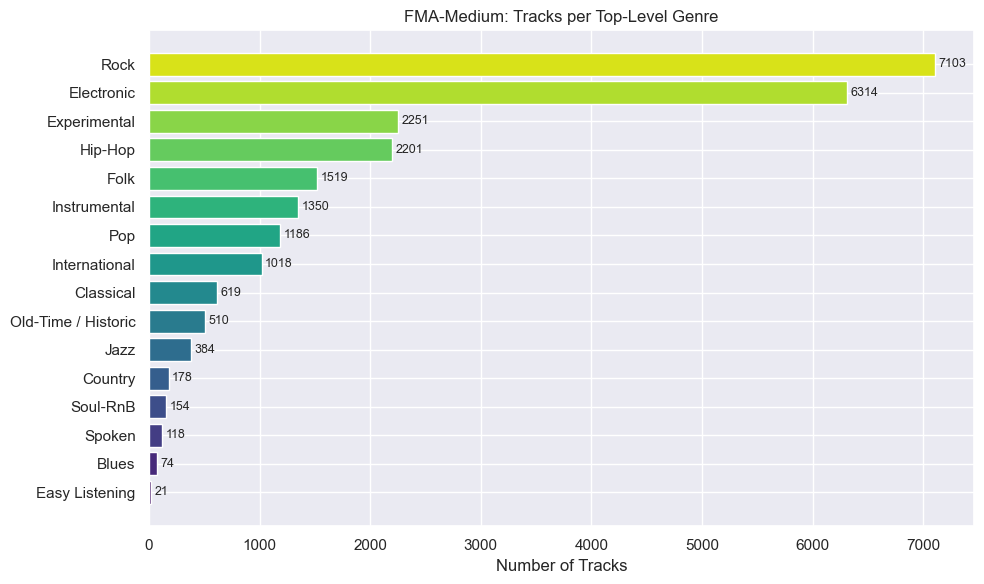

In [9]:
# Summary stats
print(f"Total tracks with genre label : {genre_counts['tracks'].sum()}")
print(f"Distinct top-level genres     : {len(genre_counts)}")
print()

# Sorted table
display(genre_counts.sort_values("tracks", ascending=False).reset_index(drop=True))

# Horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))
df_sorted = genre_counts.sort_values("tracks")
ax.barh(df_sorted["genre"], df_sorted["tracks"], color=sns.color_palette("viridis", len(df_sorted)))
ax.set_xlabel("Number of Tracks")
ax.set_title("FMA-Medium: Tracks per Top-Level Genre")
for i, v in enumerate(df_sorted["tracks"]):
    ax.text(v + 30, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 9. Select Top 10 Broad Genres with Sufficient Samples

Pick the 10 genres with the most tracks, requiring a minimum sample count.

In [10]:
MIN_SAMPLES = 200          # minimum tracks to be usable
TOP_N       = 10           # genres to keep

eligible = genre_counts[genre_counts["tracks"] >= MIN_SAMPLES]
selected = eligible.nlargest(TOP_N, "tracks").reset_index(drop=True)

print(f"Selected {len(selected)} genres (min {MIN_SAMPLES} tracks each):\n")
for _, row in selected.iterrows():
    print(f"  {row['genre']:<20s}  {row['tracks']:>5d} tracks")

total_selected = selected["tracks"].sum()
total_all      = genre_counts["tracks"].sum()
print(f"\nTotal tracks covered : {total_selected} / {total_all}  "
      f"({total_selected / total_all:.1%})")

SELECTED_GENRES = selected["genre"].tolist()
print(f"\nSELECTED_GENRES = {SELECTED_GENRES}")

Selected 10 genres (min 200 tracks each):

  Rock                   7103 tracks
  Electronic             6314 tracks
  Experimental           2251 tracks
  Hip-Hop                2201 tracks
  Folk                   1519 tracks
  Instrumental           1350 tracks
  Pop                    1186 tracks
  International          1018 tracks
  Classical               619 tracks
  Old-Time / Historic     510 tracks

Total tracks covered : 24071 / 25000  (96.3%)

SELECTED_GENRES = ['Rock', 'Electronic', 'Experimental', 'Hip-Hop', 'Folk', 'Instrumental', 'Pop', 'International', 'Classical', 'Old-Time / Historic']


## 10. Visualize Final Genre Selection

Polished bar chart of the 10 selected genres with annotated counts.

Figure saved → reports/fma_genre_selection.png


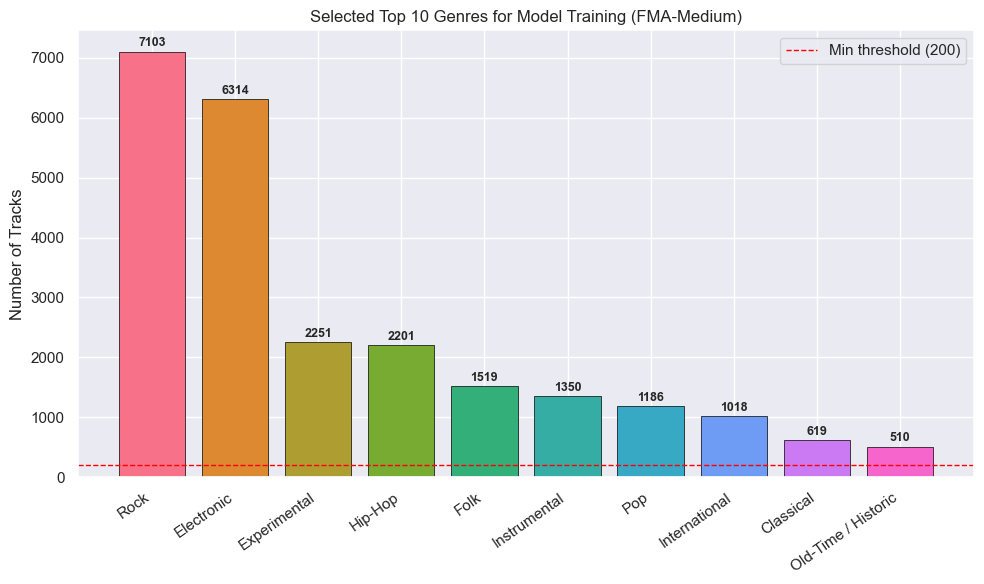


── Final Genre Selection ──────────────────────────────


genre,tracks
Rock,7103
Electronic,6314
Experimental,2251
Hip-Hop,2201
Folk,1519
Instrumental,1350
Pop,1186
International,1018
Classical,619
Old-Time / Historic,510


In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("husl", len(selected))
bars = ax.bar(selected["genre"], selected["tracks"], color=colors, edgecolor="black", linewidth=0.5)

# Annotate each bar
for bar, count in zip(bars, selected["tracks"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 40,
            str(count), ha="center", va="bottom", fontsize=9, fontweight="bold")

# Minimum threshold line
ax.axhline(y=MIN_SAMPLES, color="red", linestyle="--", linewidth=1, label=f"Min threshold ({MIN_SAMPLES})")

ax.set_ylabel("Number of Tracks")
ax.set_title("Selected Top 10 Genres for Model Training (FMA-Medium)")
ax.legend()
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

# Save figure
report_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), "reports")
os.makedirs(report_dir, exist_ok=True)
fig.savefig(os.path.join(report_dir, "fma_genre_selection.png"), dpi=150)
print(f"Figure saved → reports/fma_genre_selection.png")
plt.show()

# Summary table
print("\n── Final Genre Selection ──────────────────────────────")
display(selected.style.hide(axis="index").set_caption("Ready for training"))